In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import sklearn
sklearn.set_config(display='text')

국민청원 데이터를 시각화해 데이터를 탐색해 본다. 청와대 국민청원은 청와대 홈페이지에 청원을 등록한 뒤 30일 동안 20만 개 이상 투표를 받으면 정부가 답변을 제공하는 서비스로 2017년 8월에 처음 시작했으며 현재는 폐지됐다. 청원으로 올라온 내용을 분석하면 당시 사회적 이슈를 확인할 수 있다.

# plotnine 시각화 라이브러리 설치

시각화 라이브러리로 plotnine을 사용하기 위해서 라이브러리를 설치하고 import 한다.  
plotnine은 통계 프로그램인 R에서 ggplot2 라이브러리 문법을 파이썬에서 거의 똑같이 사용할 수 있는 라이브러리이다.

In [2]:
# !pip install plotnine

In [3]:
from plotnine import *

# 데이터 불러오기

## 불러온 데이터 살펴보기

국민 청원 데이터 파일(petition.csv)을 데이터프레임 형태로 불러온다.

`index_col`: csv 파일을 읽어들일 때 지정한 열을 행 인덱스로 사용하도록 지정한다.  
`parse_dates`: csv 파일을 읽어들일 때 지정한 열의 데이터 타입을 datetime 형태로 변환한다.  

parse_dates 속성이 자동으로 인식하고 파싱할 수 있는 날짜 및 시간 데이터 형태  
날짜: `2026-08-25`, `2026/08/25`, `2026.08.25`, `20260825`  
날짜 및 시간: `2026-08-25 12:43:41`, `2026-08-25T12:43:41`, `2026-08-25 12:43:41.123456`


고유번호(article_id), 시작일(start), 종료일(end), 답변 여부(answered), 투표수(votes), 종류(category), 제목(title), 내용(content)

In [4]:
petitions = pd.read_csv('./data/petition.csv', index_col='article_id', parse_dates=['start', 'end'])
print(petitions.shape)
petitions.head()

(395547, 7)


,start,end,answered,votes,category,title,content
article_id,,,,,,,
21,2017-08-19,2017-11-17,0,9,안전/환경,스텔라 데이지호에 대한 제안입니다.,스텔라 데이지호에 대한 제안입니다.\n3월31일 스텔라 데이지호가 침몰하고 5달째가...
22,2017-08-19,2017-11-17,0,17,기타,비리제보처를 만들어주세요.,현 정부에 국민들이 가장 원하는 것은 부패척결입니다. 우리 사회에 각종 비리들이 ...
23,2017-08-19,2017-09-03,0,0,미래,제2의 개성공단,"만일 하시는 대통령님 및 각 부처 장관님,주무관님들 안녕하세요!!\n전남 목포에서 ..."
24,2017-08-19,2017-08-26,0,53,일자리,공공기관 무조건적인 정규직전환을 반대합니다.,현정부에서 정규직 일자리를 늘리는 것에 찬성합니다. 그런데 공공기관 비정규직들은 인...
25,2017-08-19,2017-09-03,0,0,미래,제2의 개성공단,"만일 하시는 대통령님 및 각 부처 장관님,주무관님들 안녕하세요!!\n전남 목포에서 ..."


csv 파일을 읽어들일 때 parse_dates 속성을 사용했으므로 start와 end 열의 데이터 타입이 datetime인 것을 확인할 수 있다.

In [5]:
petitions.info()

<class 'pandas.DataFrame'>
Index: 395547 entries, 21 to 517122
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   start     395547 non-null  datetime64[us]
 1   end       395547 non-null  datetime64[us]
 2   answered  395547 non-null  int64         
 3   votes     395547 non-null  int64         
 4   category  395547 non-null  str           
 5   title     395547 non-null  str           
 6   content   395546 non-null  str           
dtypes: datetime64[us](2), int64(2), str(3)
memory usage: 24.1 MB


In [6]:
petitions.columns

Index(['start', 'end', 'answered', 'votes', 'category', 'title', 'content'], dtype='str')

In [7]:
petitions.describe()

,start,end,answered,votes
count,395547,395547,395547.000000,3.955470e+05
mean,2018-05-26 13:51:50.767620,2018-06-26 11:25:26.537175,0.000073,1.501188e+02
min,2017-08-19 00:00:00,2017-08-26 00:00:00,0.000000,0.000000e+00
25%,2018-01-26 00:00:00,2018-02-25 00:00:00,0.000000,2.000000e+00
50%,2018-05-30 00:00:00,2018-06-29 00:00:00,0.000000,5.000000e+00
75%,2018-09-20 00:00:00,2018-10-20 00:00:00,0.000000,1.500000e+01
max,2019-02-04 00:00:00,2019-03-06 00:00:00,1.000000,1.192049e+06
std,NaN,NaN,0.008562,4.802583e+03


## 결측치가 있는지 확인하기

결측치란 말 그대로 데이터에 값이 없는 것을 말한다. 결측치는 사용하는 프로그래밍 언어마다 여러 가지로 표현되는데 머신러닝 알고리즘 내부에서 결측치를 연산 할 수 없기 때문에 오류가 발생한다. 따라서, 데이터를 볼 때는 항상 결측치를 주의해야 한다. 머신러닝 알고리즘으로 모델을 만들 때는 dropna()를 통해 결측지를 제거하거나 0과 같은 숫자로 대체하기도 한다.

isnull().sum() 명령을 실행해서 결측치가 있는지 확인해 본다.

In [8]:
petitions.isnull().sum()

start       0
end         0
answered    0
votes       0
category    0
title       0
content     1
dtype: int64

# 판다스 데이터 분석과 시각화

## 답변 대상 청원 열 추가

answered 항목은 청와대에서 답변했는지 여부를 알 수 있는 열이다. 그런데 데이터 중에는 답변 대기 중인 청원도 있으므로 이를 확인한다. 관계 연산자를 이용해 20만 개 이상 투표를 받아 답변 대상인 청원에 대해 answer라는 파생 변수를 추가한다.

In [9]:
petitions['answer'] = petitions.votes >= 200000
petitions.shape

(395547, 8)

shape을 실행해 보면 열이 8개로 하나 늘었다. 투표가 20만 개가 넘는 청원은 True, 나머지는 False로 채워지고 False가 대부분이지만 아래와 같이 살펴보면 True인 부분을 확인할 수 있다.

In [10]:
petitions[petitions.answer == True].head()

,start,end,answered,votes,category,title,content,answer
article_id,,,,,,,,
1785,2017-09-03,2017-11-02,1,296330,인권/성평등,청소년이란 이유로 보호법을 악용하는 잔인무도한 청소년들이 늘어나고있습니다. 반드시 ...,안녕하십니까. 청소년보호법이란 명목하에 나쁜짓을 일삼는 청소년들이 너무나 많아지고 ...,True
10949,2017-09-06,2017-12-05,1,615354,미래,조두순 출소반대,제발 조두순 재심다시해서 무기징역으로 해야됩니다!!!,True
18278,2017-09-30,2017-10-30,1,235372,인권/성평등,낙태죄 폐지와 자연유산 유도약(미프진) 합법화 및 도입을 부탁드립니다.,안녕하세요. 존경하는 대통령님 의원님\n낙태죄 폐지를 청원합니다.\n현재 대한민국은...,True
26024,2017-11-04,2017-12-04,1,216774,안전/환경,'주취감형(술을 먹으면 형벌 감형)' 폐지를 건의(청원)합니다.,"'주취감형'이란, 술을 먹고 범행을 저지를 때, 심신미약 (이성이 없고 우발적)이라...",True
45581,2017-11-17,2017-12-17,1,281985,보건복지,"권역외상센터 (이국종 교수님) 추가적, 제도적, 환경적, 인력 지원","청원사항)\n중증외상분야의 추가적, 제도적, 환경적, 인력 지원 방안마련\n현 의료...",True


## 청원 기간별 분석

청원 기간을 알아보기 위해 청원이 끝난 날인 end 열에서 청원을 시작한 날인 start 열의 날짜를 빼서 duration이라는 파생 변수를 추가한다.

In [11]:
petitions['duration'] = petitions['end'] - petitions['start']
petitions.head()

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,
21,2017-08-19,2017-11-17,0,9,안전/환경,스텔라 데이지호에 대한 제안입니다.,스텔라 데이지호에 대한 제안입니다.\n3월31일 스텔라 데이지호가 침몰하고 5달째가...,False,90 days
22,2017-08-19,2017-11-17,0,17,기타,비리제보처를 만들어주세요.,현 정부에 국민들이 가장 원하는 것은 부패척결입니다. 우리 사회에 각종 비리들이 ...,False,90 days
23,2017-08-19,2017-09-03,0,0,미래,제2의 개성공단,"만일 하시는 대통령님 및 각 부처 장관님,주무관님들 안녕하세요!!\n전남 목포에서 ...",False,15 days
24,2017-08-19,2017-08-26,0,53,일자리,공공기관 무조건적인 정규직전환을 반대합니다.,현정부에서 정규직 일자리를 늘리는 것에 찬성합니다. 그런데 공공기관 비정규직들은 인...,False,7 days
25,2017-08-19,2017-09-03,0,0,미래,제2의 개성공단,"만일 하시는 대통령님 및 각 부처 장관님,주무관님들 안녕하세요!!\n전남 목포에서 ...",False,15 days


In [12]:
petitions.sort_values('duration', ascending=False).head()

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,
21,2017-08-19,2017-11-17,0,9,안전/환경,스텔라 데이지호에 대한 제안입니다.,스텔라 데이지호에 대한 제안입니다.\n3월31일 스텔라 데이지호가 침몰하고 5달째가...,False,90 days
10821,2017-09-06,2017-12-05,0,9,문화/예술/체육/언론,평창올림픽 조직위원회의 사기행각을 고발합니다.,"평창올림픽 조직위원회의 사기행각을 고발합니다.\n저는 피겨 스케이팅 팬으로, 한국에...",False,90 days
5858,2017-09-05,2017-12-04,0,1,기타,청소년법 폐지 찬성합니다.,미성년자라고 해서 강력형사 범죄자들까지 보호할 필요는 없습니다.\n다른 사람을 죽이...,False,90 days
10805,2017-09-06,2017-12-05,0,2,안전/환경,소년법폐지,소년법 폐지 동의합니다,False,90 days
10806,2017-09-06,2017-12-05,0,5,인권/성평등,청소년법폐지,청소년법은 청소년을 보호하는게 아닙니다\n청소년들을 악마로 또는 피해자로 만들뿐입니다.,False,90 days


value_counts() 메소드로 청원 기간을 확인해 보면 30일이 가장 많고 90일, 7일 순으로 많다.

In [13]:
petitions.duration.value_counts()

duration
30 days    384347
90 days      6754
7 days       2436
15 days      1204
60 days       806
Name: count, dtype: int64

청원 기간이 90일이고 답변 대상인 건에는 어떤 청원이 있는지 살펴본다.  
연산을 통해 값을 비교하면 결과가 True, False로 나오는데 이 결과를 데이터프레임으로 다시 감싸면 True로 된 행만 가져온다. 이 방법은 True 또는 False로 나오는 bool 값으로 결과값을 색인해 오기 때문에, boolean indexing이라고도 한다.

In [14]:
petitions[(petitions.duration == '90 days') & (petitions.answer == True)]

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,
10949,2017-09-06,2017-12-05,1,615354,미래,조두순 출소반대,제발 조두순 재심다시해서 무기징역으로 해야됩니다!!!,True,90 days


In [15]:
petitions[(petitions.duration == '60 days') & (petitions.answer == True)]

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,
1785,2017-09-03,2017-11-02,1,296330,인권/성평등,청소년이란 이유로 보호법을 악용하는 잔인무도한 청소년들이 늘어나고있습니다. 반드시 ...,안녕하십니까. 청소년보호법이란 명목하에 나쁜짓을 일삼는 청소년들이 너무나 많아지고 ...,True,60 days


In [16]:
petitions[(petitions.duration == '30 days') & (petitions.answer == True)]

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,
18278,2017-09-30,2017-10-30,1,235372,인권/성평등,낙태죄 폐지와 자연유산 유도약(미프진) 합법화 및 도입을 부탁드립니다.,안녕하세요. 존경하는 대통령님 의원님\n낙태죄 폐지를 청원합니다.\n현재 대한민국은...,True,30 days
26024,2017-11-04,2017-12-04,1,216774,안전/환경,'주취감형(술을 먹으면 형벌 감형)' 폐지를 건의(청원)합니다.,"'주취감형'이란, 술을 먹고 범행을 저지를 때, 심신미약 (이성이 없고 우발적)이라...",True,30 days
45581,2017-11-17,2017-12-17,1,281985,보건복지,"권역외상센터 (이국종 교수님) 추가적, 제도적, 환경적, 인력 지원","청원사항)\n중증외상분야의 추가적, 제도적, 환경적, 인력 지원 방안마련\n현 의료...",True,30 days
49083,2017-11-24,2017-12-24,1,211064,기타,"전안법. 18살, 미성년자에게 정부가 직접 찍어주는 범죄자 낙인!","3년 이하의 징역, 또는3천만원 이하의 벌금. 혹은 500만원 이하의 과태료.\n설...",True,30 days
57132,2017-12-03,2018-01-02,1,255554,성장동력,전안법 합리적으로 개정 또는 폐지해주세요.(소상공인 소비자 모두 죽는법안입니다.),2017년 1월 28일부터 시행되는 법령으로 국가기술표준원에서 관리하는 전기제품에만...,True,30 days
...,...,...,...,...,...,...,...,...,...
472309,2018-12-18,2019-01-17,0,269110,인권/성평등,조재범 코치를 강력처벌해주세요,그는 국가대표 심석희 외 다수의 여자선수들을 지속적으로 적어도 14년간 폭행해온 쓰...,True,30 days
489302,2019-01-07,2019-02-06,0,302856,정치개혁,여.야는 속히 공수처 신설하라 !!!,지금 대한 민국은 나라를 바로 잡기 위해 반드시 이번 정부내에 검찰과 법원의 확실한...,True,30 days
510422,2019-01-29,2019-02-28,0,312197,기타,"경사 ***, 경장 *** 외 ***에서 뇌물받는지 조사부탁드립니다.","경사 ***, 경장 *** 등등 ***에서 뇌물받는지 조사부탁드립니다.\nㅡㅡㅡㅡㅡ...",True,30 days


In [17]:
petitions[(petitions.duration == '15 days') & (petitions.answer == True)]

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,


In [18]:
petitions[(petitions.duration == '7 days') & (petitions.answer == True)]

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,


## 청원 기간과 분야별 분석

이번에는 어느 분야의 청원이 가장 많이 들어왔는지 확인해 본다.

In [19]:
category_df = pd.DataFrame(petitions.category.value_counts()).reset_index()
category_df.columns = ['category', 'counts']
category_df

,category,counts
0,정치개혁,62750
1,기타,48682
2,인권/성평등,34993
3,안전/환경,30638
4,교통/건축/국토,28184
5,외교/통일/국방,26626
6,육아/교육,25537
7,보건복지,24848
8,일자리,23225
9,행정,20268


청원이 가장 많이 들어온 날은 언제인지 확인해 본다.

In [20]:
start_df = pd.DataFrame(petitions.start.value_counts()).reset_index()
start_df.columns = ['start', 'counts']
print('청원 접수: {}일'.format(start_df.shape[0]))
start_df.head()

청원 접수: 535일


,start,counts
0,2017-11-11,9623
1,2017-09-05,5952
2,2018-01-11,3368
3,2018-02-06,2631
4,2017-11-09,2487


2017년 11월 11일과 9월 5일에 청원이 폭발적으로 많았다. 그렇다면 청원이 많았던 날 또는 청원이 많았던 분야에 투료도 많이 일어났을까? 둘의 관계를 파악하기 위해 먼저 피벗 테이블 기능으로 투표가 가장 많이 일어난 분야를 확인해 본다.

In [21]:
petitions_unique = pd.pivot_table(petitions[['category', 'answer', 'answered', 'votes']], index='category', aggfunc=np.sum)
petitions_best = petitions_unique.sort_values(by='votes', ascending=False).reset_index()
petitions_best

,category,answer,answered,votes
0,인권/성평등,24,9,12559348
1,안전/환경,10,2,6605175
2,정치개혁,8,2,6205013
3,기타,8,1,5190468
4,육아/교육,3,1,4475297
5,보건복지,3,2,4341211
6,문화/예술/체육/언론,7,4,4149796
7,외교/통일/국방,4,1,3696112
8,교통/건축/국토,3,2,2902330
9,반려동물,4,0,2066624


결과를 보면 투표를 가장 많이 받았던 분야는 인권/성평등이다. 앞에서 확인한 청원이 가장 많았던 분야인 정치개혁 분야는 투표수가 3번째로 많은 것으로 나타났다. 이것으로 청원 빈도수와 투표수가 항상 비례하지 않음을 알 수 있다.

투표를 가장 많이 받았던 날을 확인해 본다.

In [22]:
petitions_start = pd.pivot_table(petitions[['start', 'answer', 'answered', 'votes']], index='start', aggfunc=np.sum)
petitions_votes = petitions_start.sort_values(by='votes', ascending=False).reset_index()
petitions_votes[petitions_votes.votes >= 600000]

,start,answer,answered,votes
0,2018-10-17,1,0,1300523
1,2018-10-31,2,0,827096
2,2018-06-13,1,0,786157
3,2018-10-18,2,0,721524
4,2018-02-19,1,1,701520
5,2018-11-09,2,0,672819
6,2018-07-22,1,0,672491
7,2017-09-06,1,1,648209
8,2018-06-24,2,0,628925
9,2018-10-04,2,1,626761


In [23]:
petitions_votes.head()

,start,answer,answered,votes
0,2018-10-17,1,0,1300523
1,2018-10-31,2,0,827096
2,2018-06-13,1,0,786157
3,2018-10-18,2,0,721524
4,2018-02-19,1,1,701520


청원이 많이 들어온 날에 투표도 많이 받았나 확인해 본다.  
청원이 많이 들어온 날을 저장한 데이터프레임(start_df)과 투표를 가장 많이 받았던 날을 저장한 데이터프레임(petitions_votes)을 merge() 메소드를 사용해서 합친다.

In [24]:
petitions_hot = start_df.merge(petitions_votes, on='start', how='left')
petitions_hot

,start,counts,answer,answered,votes
0,2017-11-11,9623,0,0,85074
1,2017-09-05,5952,0,0,48808
2,2018-01-11,3368,0,0,44570
3,2018-02-06,2631,0,0,83038
4,2017-11-09,2487,0,0,34774
...,...,...,...,...,...
530,2017-09-15,74,0,0,776
531,2017-08-22,69,0,0,2607
532,2017-08-27,49,0,0,7147
533,2017-08-19,39,0,0,20703


판다스의 nlargest() 메소드는 데이터프레임의 특정 열을 기준으로 값이 큰 상위 n개의 행을 추출한다.

In [25]:
petitions_hot.nlargest(5, 'votes')

,start,counts,answer,answered,votes
116,2018-10-17,926,1,0,1300523
81,2018-10-31,1010,2,0,827096
384,2018-06-13,542,1,0,786157
73,2018-10-18,1032,2,0,721524
270,2018-02-19,698,1,1,701520


In [26]:
petitions_hot.nlargest(5, 'counts')

,start,counts,answer,answered,votes
0,2017-11-11,9623,0,0,85074
1,2017-09-05,5952,0,0,48808
2,2018-01-11,3368,0,0,44570
3,2018-02-06,2631,0,0,83038
4,2017-11-09,2487,0,0,34774


청원이 20만 개 이상의 투표를 받으면 청와대로부터 답변을 받을 수 있다. 투표수 20만 개 이상인 답변 대상 청원은 몇 건인가 살펴본다.

In [27]:
answer_df = petitions[petitions.answer]
answered_df = petitions[petitions.answered == 1]
print('답변 대상 청원 {}건 중에서 실제 청와대가 답변한 청원 건수는 {}건 입니다.'.format(answer_df.shape[0], answered_df.shape[0]))

답변 대상 청원 80건 중에서 실제 청와대가 답변한 청원 건수는 29건 입니다.


## plotnine으로 시각화

카테고리별로 집계된 국민청원 데이터를 plotnine에 있는 ggplot() 함수를 사용해 시각화 한다.

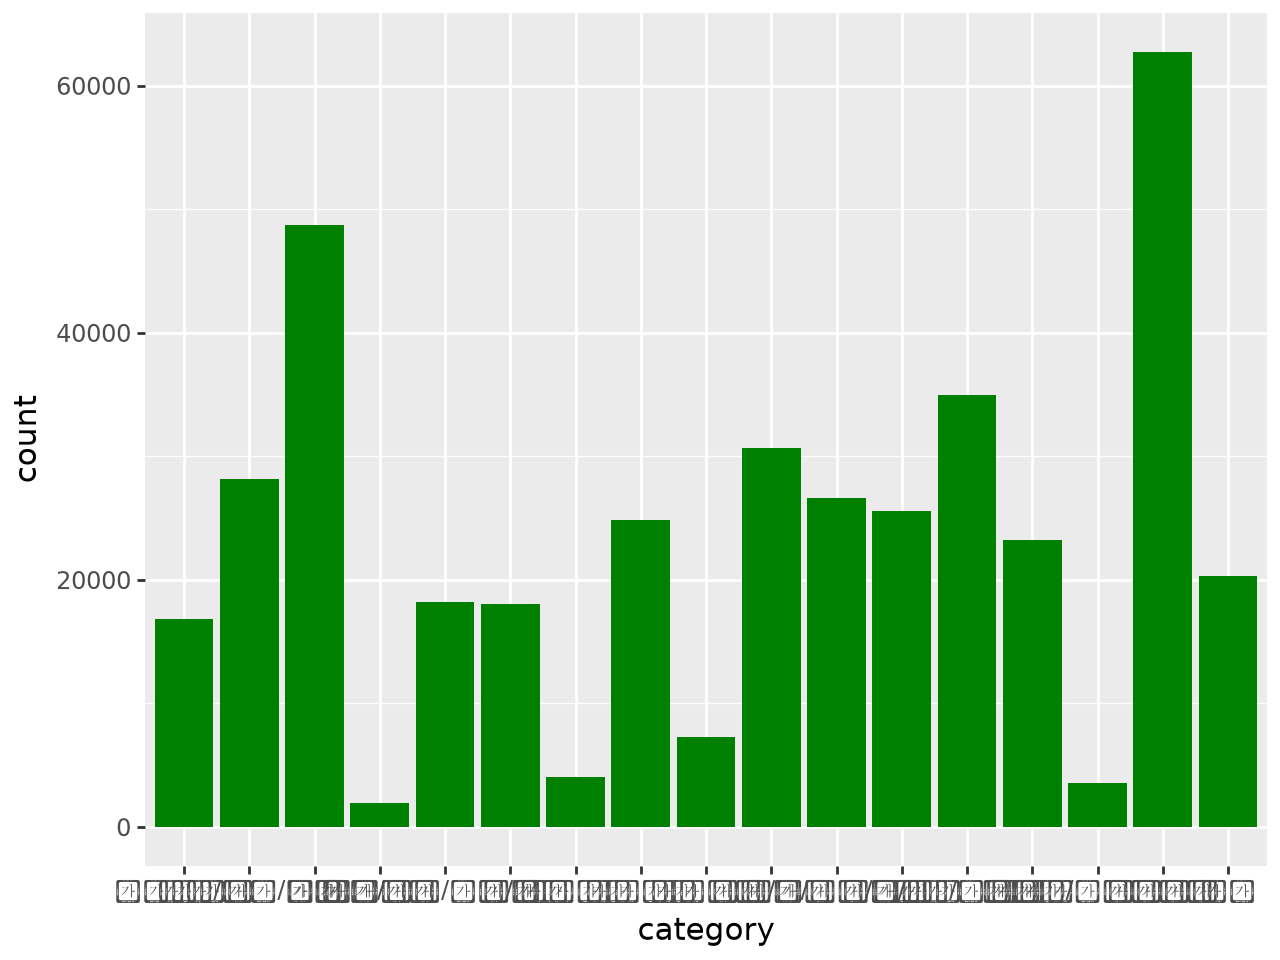

In [28]:
(
    ggplot(petitions)
        + aes('category')
        + geom_bar(fill='green')
)

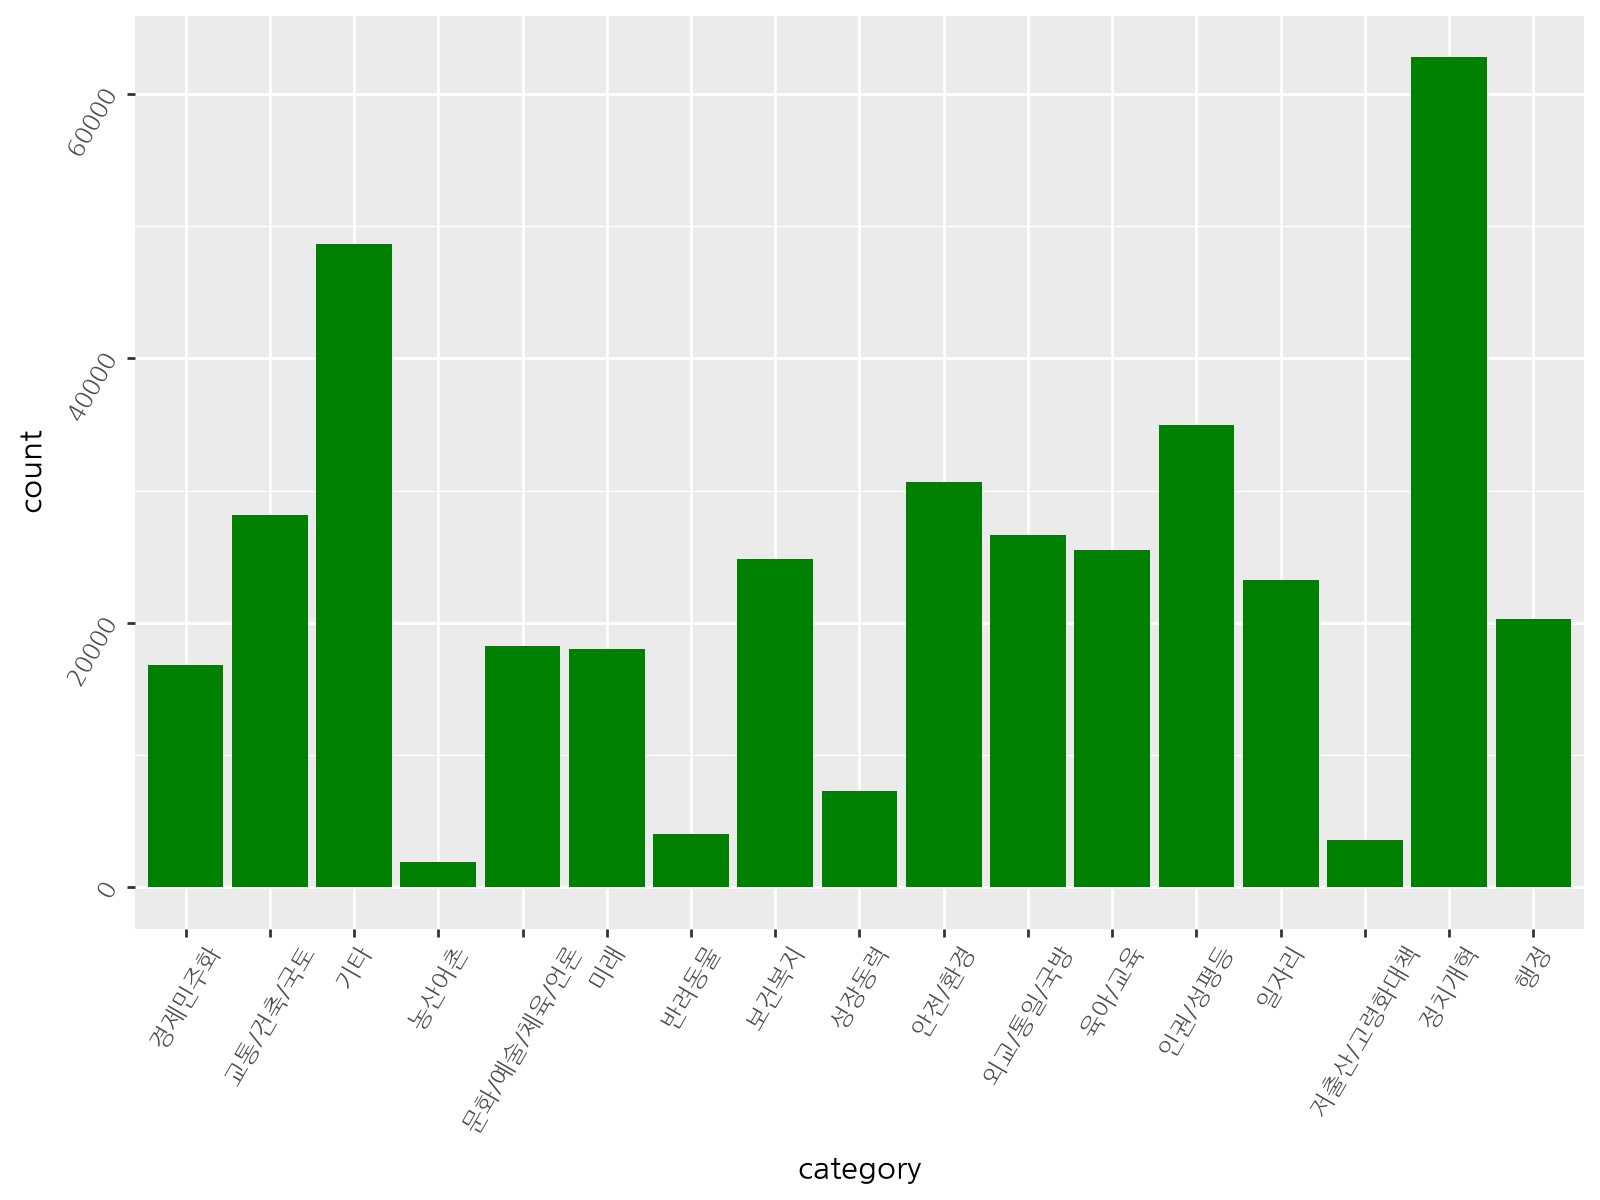

In [29]:
(
    ggplot(petitions)
        + aes('category')
        + geom_bar(fill='green')
        + theme(text=element_text(family='NanumGothic'), axis_text=element_text(rotation=60), figure_size=(8, 6))
)

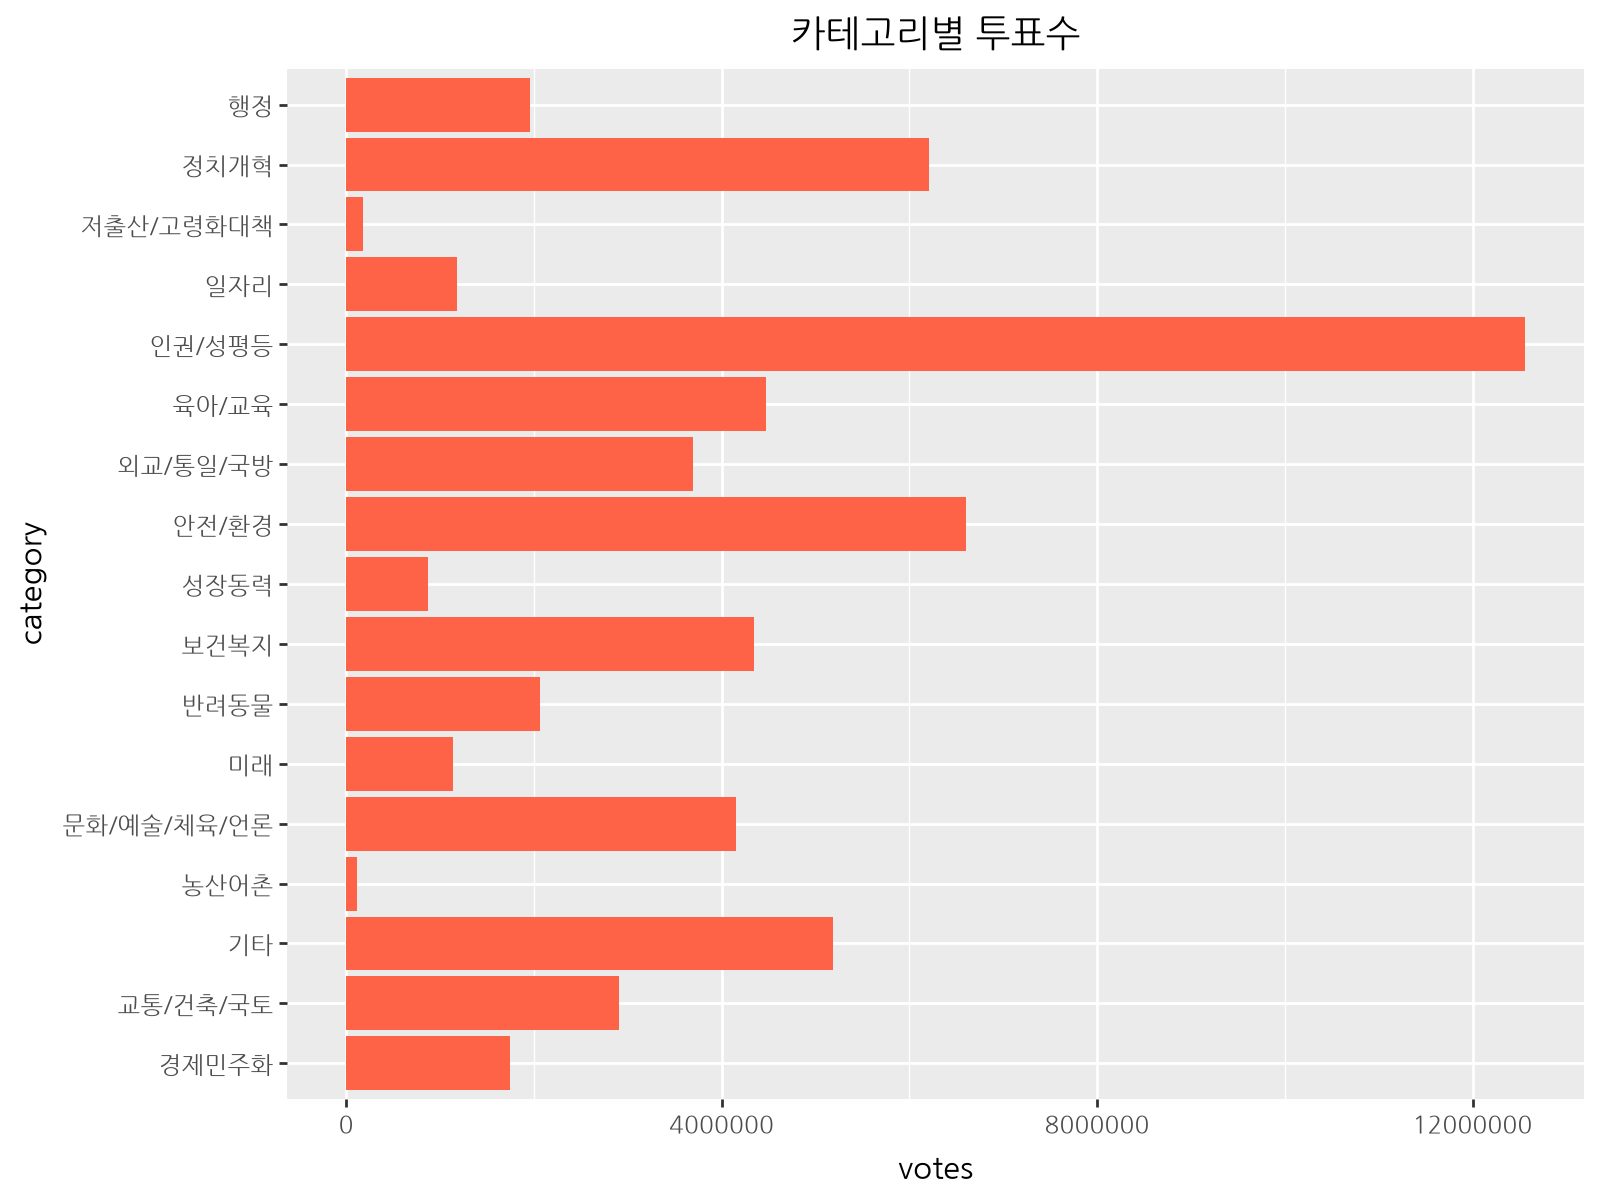

In [30]:
(
    ggplot(petitions)
        + aes('category', 'votes')
        + geom_col(fill='tomato')
        + theme(text=element_text(family='NanumGothic'), figure_size=(8, 6))
        + ggtitle('카테고리별 투표수')
        + coord_flip()
)

투표를 가장 많이 받은 카테고리인 인권/성평등에서 투표를 많이 받은 순으로 출력해 본다.

In [31]:
human = petitions[petitions.category == '인권/성평등']
human.sort_values('votes', ascending=False).head(3)

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,
230552,2018-05-11,2018-06-10,1,419006,인권/성평등,여성도 대한민국 국민입니다. 성별 관계없는 국가의 보호를 요청합니다.,최근 홍대 누드크로키 모델의 불법촬영 사건이 있었습니다.\n사건은 굉장히 빠르게 처...,True,30 days
426834,2018-10-31,2018-11-30,0,416093,인권/성평등,"132cm, 31kg의 왜소한 50대 여성이 180cm가 넘는 건장한 20세 남성에...",http://m.news1.kr/articles/?3464603\n관련 기사입니다....,True,30 days
437737,2018-11-09,2018-12-09,0,397079,인권/성평등,억울하게 떠나신 저의 아버지의 원한을 풀어주세요,46일동안 눈 한번 뜨시지 못한 채 11월 6일 새벽 4시에 저의 아버지가 억울하게...,True,30 days


In [32]:
human.sort_values('votes', ascending=False)[:3]

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,
230552,2018-05-11,2018-06-10,1,419006,인권/성평등,여성도 대한민국 국민입니다. 성별 관계없는 국가의 보호를 요청합니다.,최근 홍대 누드크로키 모델의 불법촬영 사건이 있었습니다.\n사건은 굉장히 빠르게 처...,True,30 days
426834,2018-10-31,2018-11-30,0,416093,인권/성평등,"132cm, 31kg의 왜소한 50대 여성이 180cm가 넘는 건장한 20세 남성에...",http://m.news1.kr/articles/?3464603\n관련 기사입니다....,True,30 days
437737,2018-11-09,2018-12-09,0,397079,인권/성평등,억울하게 떠나신 저의 아버지의 원한을 풀어주세요,46일동안 눈 한번 뜨시지 못한 채 11월 6일 새벽 4시에 저의 아버지가 억울하게...,True,30 days


In [33]:
human.nlargest(3, 'votes')

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,
230552,2018-05-11,2018-06-10,1,419006,인권/성평등,여성도 대한민국 국민입니다. 성별 관계없는 국가의 보호를 요청합니다.,최근 홍대 누드크로키 모델의 불법촬영 사건이 있었습니다.\n사건은 굉장히 빠르게 처...,True,30 days
426834,2018-10-31,2018-11-30,0,416093,인권/성평등,"132cm, 31kg의 왜소한 50대 여성이 180cm가 넘는 건장한 20세 남성에...",http://m.news1.kr/articles/?3464603\n관련 기사입니다....,True,30 days
437737,2018-11-09,2018-12-09,0,397079,인권/성평등,억울하게 떠나신 저의 아버지의 원한을 풀어주세요,46일동안 눈 한번 뜨시지 못한 채 11월 6일 새벽 4시에 저의 아버지가 억울하게...,True,30 days


일별 투표수를 시각화해 본다.  
투표수의 증감 추이를 시각화 하기 위해 groupby() 메소드로 청원 시작일(start)로 부터 투표수(votes)를 구한다.

In [34]:
petitions_votes = petitions.groupby(['start'])['votes'].sum().reset_index()
petitions_votes.head()

,start,votes
0,2017-08-19,20703
1,2017-08-20,31710
2,2017-08-21,1884
3,2017-08-22,2607
4,2017-08-23,13446


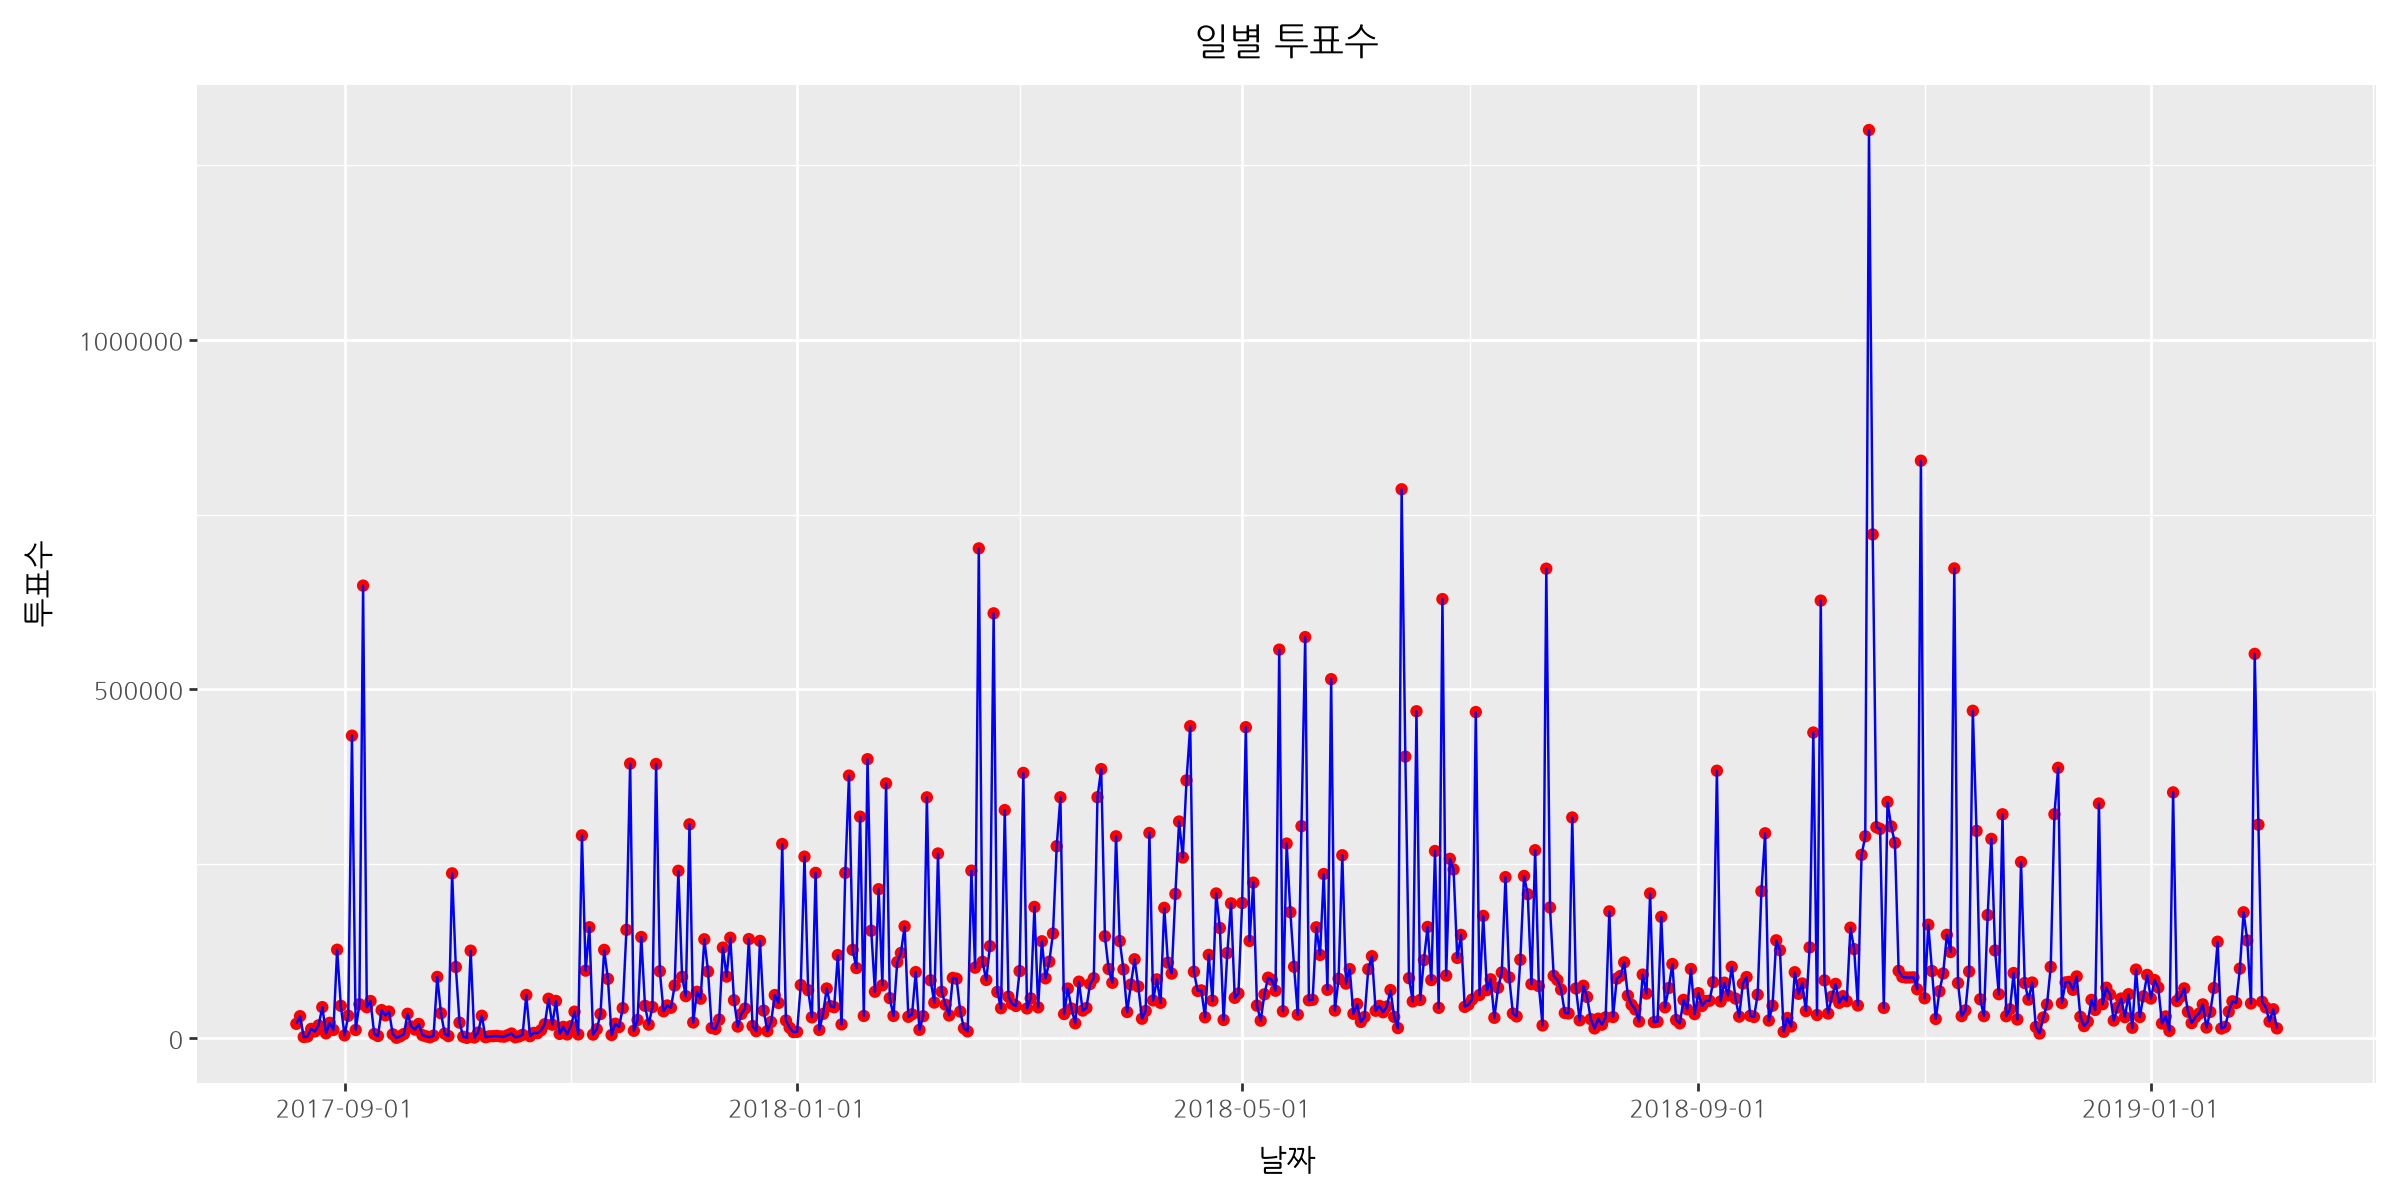

In [35]:
(
    ggplot(petitions_votes)
        + aes('start', 'votes')
        + geom_point(color='red')
        + geom_line(color='blue')
        + theme(text=element_text(family='NanumGothic'), figure_size=(12, 6))
        + labs(x='날짜', y='투표수', title='일별 투표수')
)

In [36]:
petitions_votes[petitions_votes.votes >= 1000000]

,start,votes
424,2018-10-17,1300523


In [37]:
petitions[(petitions.start == '2018-10-17') & (petitions.votes >= 1000000)]

,start,end,answered,votes,category,title,content,answer,duration
article_id,,,,,,,,,
408609,2018-10-17,2018-11-16,0,1192049,안전/환경,강서구 피시방 살인 사건. 또 심신미약 피의자입니다.,2018년 10월 14일 엊그제 일어난 강서구 피시방 살인사건에 대한 청원입니다.\...,True,30 days


# 워드클라우드

soynlp는 기존 형태소 분석기에 비해 신조어에 대응할 수 있도록 만들어졌으며 파이썬으로 작성된 한국어 분석 도구로 비지도 학습을 지향한다.  

soynlp 라이브러리를 사용하기 위해 설치하고 import 한다.

In [38]:
# !pip install soynlp

In [ ]:
df = pd.read_csv('./data/petition.csv', index_col='article_id', parse_dates=['start', 'end'])
print(df.shape)
df.head()

자신의 관심사에 맞는 단어로 데이터를 가져오려면 파이썬의 re(정규 표현식) 라이브러리에서 제공하는 match() 메소드를 사용한다. match() 메소드는 문자열이 정규식에서 지정된 패턴과 일치하는지 확인하기 위해 문자열을 검색하고 일치하는 단어를 반환한다.

육아, 초등, 돌봄, 보육 등의 키워드가 들어있는 제목과 내용을 추출해 보자. 추출하려는 단어가 여러 개이므로 `|`를 사용해 찾으려는 단어를 병렬로 나열한다.

`r'.*(육아|초등|돌봄|보육).*'`은 문자열 내에 지정한 단어 중 하나라도 포함되어 있는지 검사하는 정규 표현식 패턴이다.  
아무 문자나 0개 이상 나오고 육아, 초등, 돌봄, 보육 중 1개가 나온 후 아무 문자나 0개 이상 나오는 문자열 패턴이다. => 포함  

`r'...'`: raw string, 역슬래시(`\`)를 이스케이프 시퀀스 문자로 처리하지 않고 있는 그대로 인식하도록 지정하는 파이썬 문자열 문법이다.  
`.`: 줄바꿈을 제외한 아무 문자에 매칭된다. 아무 문자 1개  
`*`: `*` 앞의 문자가 0개 이상 반복되는 것을 의미한다.  
`+`: `+` 앞의 문자가 1개 이상 반복되는 것을 의미한다.  
`(...)`: 그룹화를 의미한다. 내부에 파이프(`|`) 연산자와 결합하여 조건을 만든다.  
`육아|초등|돌봄|보육`: `|`는 OR 연산자로 사용되며 육아, 초등, 돌봄, 교육 4개의 단어 중 하나라도 일치하면 조건을 지정한다.

In [ ]:
pattern = r'.*(육아|초등|돌봄|보육).*'
care = df[df.title.str.match(pattern) | df.content.str.match(pattern)]
care.shape

In [ ]:
care.head()

샘플로 보고싶은 인덱스 번호로 특정 청원의 제목과 내용을 확인할 수 있다.

In [ ]:
sample_index = 24
sample_title = care.loc[sample_index, 'title']
sample_title

In [ ]:
sample_content = care['content'][sample_index]
sample_content

# 토큰화

관심사에 맞는 데이터를 가져왔다면, 띄어쓰기(공백)를 기준으로 나누어 준다. 이를 토큰화라고 한다.  
soynlp 라이브러리에서 제공하는 RegexTokenizer를 토크나이저로 사용하기 위해 import 한다.

In [ ]:
from soynlp.tokenizer import RegexTokenizer

In [ ]:
tokenizer = RegexTokenizer()
tokenizer

RegexTokenizer의 tokenize() 메소드로 토큰화 하면 띄어쓰기를 기준으로 잘 나눠진 것을 확인할 수 있다.

In [ ]:
tokened_title = tokenizer.tokenize(sample_title)
tokened_title

In [ ]:
tokened_content = tokenizer.tokenize(sample_content)
tokened_content[:20]

제목과 내용의 토큰 개수를 알아보자.

In [ ]:
print(len(tokened_title), len(tokened_content))

# 워드클라우드

## 워드클라우드를 그리기 전에 텍스트 데이터를 전처리 한다.

줄을 바꾸기 위해 사용된 개행 문자(\n)는 시각화할 때 불필요한 정보이므로 제거한다. 그리고 한글과 영문자가 아닌 불필요한 문자들도 제거한다.

정규 표현식 패턴으로 개행 문자를 찾으려면 역슬래시(\)는 2개를 연속해야 써야 1개로 인식한다.  
일반 패턴을 사용할 경우에는 `'\\\\n'` 처럼 4개를 사용하거나 파이썬 raw string을 사용하면 `r'\\n'` 형태로 사용해야 한다.

In [ ]:
# 문장 속의 개행 문자를 모두 찾아서 공백으로 치환한다.
# regex 속성값으로 True를 지정하면 replace() 메소드의 첫 번째 인수가 단순 텍스트가 아닌 정규 표현식으로 해석한다.
content_text = care.content.str.replace(r'\\n', ' ', regex=True)
# 문장 속의 숫자나 특수 문자(!, @, # 등)를 모두 찾아서 공백으로 치환한다. 깨끗한 한글과 영어 텍스트만 남는다.
# [^...]: [] 안의 ^는 부정을 의미하며 [] 안에 나열된 것이 아닌 것을 의미한다.
# ㄱ-ㅎ: 한글 자음만, ㅏ-ㅣ: 한글 모음만, ㄱ-힣: 한글 전체, a-z: 영문 소문자, A-Z: 영문 대문자, 0-9: 숫자
content_text = care.content.str.replace(r'[^ㄱ-힣a-zA-Z]', ' ', regex=True)
content_text.head()

정규 표현식을 이용해서 불필요한 텍스트를 제거한 후 한 줄로 표현되는 문장을 토큰별로 나눠준다.

토큰별로 나눠주는 과정을 모든 content_text 시리즈에 일괄 적용하기 위해서 apply() 메소드의 인수로 RegexTokenizer의 tokenize() 메소드를 넘겨준다.

In [ ]:
tokens = content_text.apply(tokenizer.tokenize)
tokens.head()

## 워드클라우드를 그리기

워드클라우드를 사용하기 위해서 wordcloud 라이브러리를 설치하고 import 한다.

In [ ]:
# !pip install wordcloud

In [ ]:
from wordcloud import WordCloud

In [ ]:
# 워드클라우드를 구현하는 함수를 선언한다.
def display_wordcloud(text):
    # 불용어 설정
    stopwords = ['하지만', '그리고', '그런데', '그래서', '그러면', '저는', '그럼', '이런', '저런', '합니다', '많은', '많이', '정말', '너무', 'n', '그',
                '수 있는', '할 수']
    # 워드클라우드 설정
    wordcloud = WordCloud(
        font_path='C:\\Users\\enjoy\\AppData\\Local\\Microsoft\\Windows\\Fonts\\NanumGothicCoding.ttf',
        width=1200,
        height=500,
        stopwords=stopwords,
        background_color='white',
        random_state=42
    ).generate(text)
    # 워드클라우드 작성
    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

In [ ]:
display_wordcloud(' '.join(content_text))

워드클라우드 출력 결과를 보면 '수', '그'와 같이 문서의 의미를 특정짓지 않는 불용어가 너무 많다. 명사만 추출하는 방식을 사용해서 다시 만든다.

## 명사만 추출해서 워드클라우드 그리기

데이터 특성을 반영한 핵심 의미를 한눈에 보기 어려운 단어들이 많이 보인다면, soynlp 라이브러리에서 제공하는 명사 추출기인 LRNounExtractor 객체를 통해 명사만 추출할 수 있다.

In [ ]:
from soynlp.noun import LRNounExtractor

LRNounExtractor의 train() 메소드의 인수로 명사만 추출할 데이터를 넘기고 extract() 메소드를 실행해서 명사를 추출한다.

In [ ]:
# verbose=True 속성을 지정하면 실행 과정을 상세하게 출력하라는 설정으로 명사 추출 과정에서 진행 상태나 로그 메시지를 출력한다.
noun_extractor = LRNounExtractor(verbose=True)
noun_extractor.train(content_text)
nouns = noun_extractor.extract()

이제 추출된 명사로 워드클라우드를 만든다.

In [ ]:
display_wordcloud(' '.join(nouns))

워드클라우드는 결과 그림처럼 주요 정보를 추출해 한눈에 볼 수 있다는 장점이 있는 반면 세분화된 정보는 보기 어렵다는 단점도 있다. 따라서 키워드 추출 시각화나 개체명 시각화 등과 같은 곳에서 적절하게 사용해야 한다.

# 머신러닝으로 국민청원 데이터 이진 분류하기

이번에는 머신러닝을 사용해 국민 청원 데이터를 이진 분류, 즉 청원의 응답 여부를 0과 1로 분류해 보자.

<img src="./학습유형도식화.png" width="700" align="left" />

이 실습은 지도학습 => 범주형 이므로 사이킷런의 분류 알고리즘을 사용한다.

## 지도학습에서 데이터셋 분리

데이터셋은 학습(training), 검증(validation), 테스트(test)용으로 나누는 것이 일반적이다. 학습용과 검증용은 실제로 시험을 보러가기 전에 얼마나 공부했는지 모의고사를 풀고 채점하는 것이다. 모의고사 문제가 10회분이 1 ~ 8회는 학습용으로 사용하고, 9회는 실전 모의고사용으로 풀고, 마지막 10회는 실제 시험인 셈이다. 따라서 데이터를 분리할 때는 학습, 검증, 테스트 셋의 분포가 전체 데이터의 분포를 반영할 수 있도록 분리해야 한다.

데이터 크기가 너무 작다면 검증 데이터셋을 생략하고 학습셋과 테스트셋으로만 구성할 수도 있다. 여기서는 국민 청원이 들어있는 텍스트 데이터의 70%를 학습에 사용하고 30%는 테스트에 사용한다. 이를 통해 예측한 답이 얼마나 정확한지 알 수 있다.

<img src="./국민청원텍스트지도학습.png" width="650" align="left" />

## 이진 분류 대상 정하기

투표가 500건을 초과하는 데이터를 가져온 뒤, 그 중 20만건 이상인 데이터는 제거한다.  
이렇게 기준을 정하는 이유는 500건 이하인 데이터는 개수가 많지만 일정한 경향을 발견하기 어렵고, 20만건 이상인 데이터는 매우 적지만 이상치에 가까운 큰 수이기 때문에 평균이 왜곡될 수 있기 때문이다.

In [ ]:
petitions_remove_outlier = petitions[(petitions.votes > 500) & (petitions.votes < 200000)].reset_index()
petitions_remove_outlier

원본은 유지하고 작업하려면 copy() 메소드로 복사본을 만들어서 작업한다.

In [ ]:
df = petitions_remove_outlier.copy()
df

In [ ]:
df[['article_id', 'answered', 'votes']].describe()

답변 여부(answered)에 대해서 분류하기에는 표준편차가 0이고 모수가 적으므로 투표수(votes)로 분석한다. 20만건 이상 투표한 데이터는 모두 제거했으므로 답변 대상인 데이터는 0건이다.

In [ ]:
df[df.answered == 1].shape

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df.votes)
plt.show()

## 평균을 기준으로 예측하기

votes_pos 파생 변수는 기본값을 0으로 설정한 후 평균 투표수를 구하고 투표수가 평균을 넘으면 1을 넣어준다.

In [ ]:
# 투표수 전체 평균 계산
votes_mean = df.votes.mean()
votes_mean

In [ ]:
# votes_pos 파생 변수에 각각의 투표수와 투표수 전체 평균을 비교해서 각각의 투표수가 크면 True, 그렇지 않으면 False를 저장한다.
df['votes_pos'] = df.votes > votes_mean
df.head()

In [ ]:
df.votes_pos.dtypes

votes_pos 파생 변수에 저장된 True는 1로 False는 0이 되로록 논리형에서 정수형으로 형변환시킨다.

In [ ]:
df['votes_pos'] = df.votes_pos.astype(int)
df.head()

전체 평균이 5,664인데 article_id가 43인 청원의 투표수가 11,293건이므로 votes_pos에 1이 저장된 것을 확인할 수 있다. 평균 대신 중위로 해봐도 의미가 있을 것이다.

In [ ]:
sample_index = 13
sample_title = df.loc[sample_index, 'title']
sample_title

In [ ]:
sample_content = df['content'][sample_index]
sample_content

## 전처리하기

정규 표현식을 사용하기 위해서 파이썬 내장 라이브러리 re를 import 한다.

In [ ]:
import re

`r' +'`의 의미는 공백(` `)이 1개 이상 반복(`+`)되는 문자열을 찾는다. 

In [ ]:
# 개행 문자, 특수 문자, 숫자를 제거하고 중복으로 생성된 공백도 제거하는 함수
def preprocessing(text):
    # 개행 문자 제거
    text = re.sub(r'\\n', ' ', text) # sub('\\\\n', ' ', text)
    # 특수 문자, 숫자 제거
    text = re.sub(r'[^ㄱ-힣a-zA-Z]', ' ', text)
    # 중복으로 생성된 공백 제거
    text = re.sub(r' +', ' ', text)
    return text

In [ ]:
pre_sample_content = preprocessing(sample_content)
pre_sample_content

In [ ]:
# 불용어를 제거하는 함수
def remove_stopwords(text):
    tokens = text.split()
    stopwords = ['저는', '있는', '있습니다', '하는', '하고', '대한', '그리고', '없는', '입니다.', '많은', '이런', '것은', '같은', '같습니다.', '없습니다.'
                '없이', '해도', '그중', '명은']
    # tokens 리스트에 저장된 데이터가 불용어(stopwords)가 아니고 2음절 이상인 데이터만 리스트로 만든다.
    text = [token for token in tokens if token not in stopwords and len(token) > 1]
    return ' '.join(text)

In [ ]:
pre_sample_content = remove_stopwords(pre_sample_content)
pre_sample_content

preprocessing() 함수와 remove_stopwords() df 데이터프레임의 content 열에 일괄 적용한 content_preprocessing 파생 변수를 추가한다.

In [ ]:
%time df['content_preprocessing'] = df.content.apply(preprocessing)

In [ ]:
%time df['content_preprocessing'] = df.content_preprocessing.apply(remove_stopwords)

In [ ]:
df['content_preprocessing'][13]

## 학습 데이터셋과 테스트 데이터셋 만들기

전처리가 끝난 데이터를 학습 데이터셋과 테스트 데이터셋으로 분리하자. 학습 데이터셋과 테스트 데이터셋은 70:30 비율로 나눠준다.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df.shape

전체 데이터 개수가 5,308개이므로 70%에 해당되는 3,715개를 학습 데이터셋으로 사용하고 나머지를 테스트 데이터셋으로 사용한다.

In [ ]:
split_count = int(df.shape[0] * 0.7)
split_count

split_count 변수를 기준으로 70:30의 비율로 데이터를 나눈다.

In [ ]:
# 학습 데이터셋
df_train = df[:split_count].copy()
df_train.shape

In [ ]:
df_train.head()

In [ ]:
df_train[df_train.votes_pos == 1].shape

In [ ]:
# 테스트 데이터셋
df_test = df[split_count:].copy()
df_test.shape

In [ ]:
df_test[df_test.votes_pos == 1].shape

## 단어 벡터화하기

단어 벡터화는 사이킷런의 CountVectorizer를 사용한다. CountVectorizer는 토큰이 문서별로 몇 번 등장했는지 희소 행렬로 정리해 준다.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
vectorizer = CountVectorizer(
    analyzer='word', # 단어(어절) 기준 벡터화
    tokenizer=None, # 토크나이저 지정
    preprocessor=None, # 전처리 도구 지정
    stop_words=None, # 불용어
    min_df=2, # 단어가 등장하는 최소 문서 개수 지정, 자주 나오지 않는 특수한 전문용어 또는 오타를 제거하기에 좋다.
    ngram_range=(1, 3), # 단어 가방을 만드는 윈도우 크기를 지정한다.
    max_features=2000, # 피쳐의 개수를 지정한다. 피쳐는 단어를 의하므로 최대 단어 개수를 지정할 수 있다.
)
vectorizer

fit_transform() 메소드는 단어 사전을 학습하고 학습한 단어와 희소 행렬을 리턴한다.

%time는 특정 문장이 실행되는 시간을 얻어오고 %%time는 특정 셀이 실행되는 시간을 얻어온다.

In [ ]:
%%time
train_feature_vector = vectorizer.fit_transform(df_train.content_preprocessing)
train_feature_vector

테스트 데이터는 transform() 메소드를 사용한다는 점을 주의한다.

In [ ]:
%%time
test_feature_vector = vectorizer.transform(df_test.content_preprocessing)
test_feature_vector

학습 데이터와 테스트 데이터의 특성 벡터(feature vector)가 출력됐다. 희소 행렬 형태이므로 벡터값은 사람이 보기에 그 의미를 직관적으로 알기 어렵다.
특성 벡터에 넘파이의 toarray() 메소드를 실행하면 넘파이 배열 형태로 단어 사전을 볼 수 있지만 단어 사전을 구성하는 단어를 확인할 수 없다.

In [ ]:
train_feature_vector.toarray()

특성 벡터 작성에 사용된 모델에 get_feature_names_out() 메소드를 실행하면 단어 사전을 구성하는 단어 목록을 확인할 수 있다.

In [ ]:
vocab = vectorizer.get_feature_names_out()
print(len(vocab))
vocab[:10]

특성 벡터에 넘파이의 toarray() 메소드를 실행한 결과를 판다스 데이터프레임으로 만들때 columns 속성에 특성 벡터 작성에 사용된 모델에 get_feature_names_out() 메소드를 실행한 결과를 넣어주면 단어 사전을 데이터프레임으로 확인할 수 있다.

In [ ]:
pd.DataFrame(train_feature_vector.toarray(), columns=vocab)

넘파이의 sum() 메소드로 데이터에 등장하는 단어들의 합계를 구해서 단어와 빈도로 짝지어진 데이터프레임으로 출력해본다.

In [ ]:
dist = np.sum(train_feature_vector, axis=0)
pd.DataFrame(dist, columns=vocab)

문서에 등장하는 단어의 빈도수를 판다스 데이터프레임 형태로 확인했다. TfidfTransformer를 사용해서 벡터 기반 머신러닝을 할 준비가 되었다.

## TF-IDF 가중치 적용하기

TfidfTransformer 라이브러리를 사용해서 TF-IDF 가중치를 적용해보자.

TfidfTransformer와 TfidfVectorizer는 모두 사이킷런에서 텍스트 데이터의 TF-IDF 값을 계산할 때 사용하지만, 입력받는 데이터 형태와 처리 과정에서 차이가 있다.  
`TfidfTransformer`는 이미 단어 빈도수가 계산된 카운트 행렬(`train_feature_vector`)을 입력받아 TF-IDF 가중치 값으로 변환해 주는 역할을 합니다.  
`TfidfVectorizer`는 `CountVectorizer`와 `TfidfTransformer` 두 가지 기능을 하나로 합쳐서 원시 텍스트를 바로 넣으면 토큰화, 단어장 생성, 빈도 수 계산, TF-IDF 변환을 한 번에 진행한다.

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer

In [ ]:
# smooth_idf 속성은 기본값은 True로 DF(문서 빈도)가 0이 되거나 IDF 값이 음수가 되는 문제를 방지하기 위해 사용하며 모든 단어가 모든 문서 집합에 기본적으로 
# 1번씩은 더 등장했다고 가정함으로써 이러한 문제를 완화해 주고 False를 사용하면 1번씩은 더 등장했다고 가정하지 않는다.
transformer = TfidfTransformer(smooth_idf=False)
transformer

fit_transform() 메소드는 단어 사전을 학습하고 학습한 단어의 TF-IDF 값이 저장된 희소 행렬을 리턴한다.

In [ ]:
train_feature_tfidf = transformer.fit_transform(train_feature_vector)
train_feature_tfidf.shape

In [ ]:
test_feature_tfidf = transformer.transform(test_feature_vector)
test_feature_tfidf.shape

## LightGBM(Light Gradient Boosting Machine)으로 학습시키기

LightGBM은 Microsoft에서 개발한 알고리즘으로 머신러닝에서 사용하는 Gradient Boosting 프레임워크 중 하나로 Gradient Boosting은 여러개의 약한 예측 모델을(보통 앝은 결정 트리)을 결합하여 강력한 성능을 내는 앙상블 기법의 하나로 기존의 Gradient Boosting 모델들의 가장 큰 단점인 '학습 시간'을 획기적으로 단축시킨 모델이다.  
리프 중심 트리 분할(Leaf-wise) 방식을 도입해 대용량 데이터에서 매우 빠른 학습 속도와 적은 메모리를 소모하는 알고리즘.

LightGBM는 사이킷런에서 지원되지 않기때문에 LightGBM를 사용하기 위해 라이브러리를 설치하고 import 한다.

In [ ]:
# !pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
# n_jobs 속성을 설정하면 여러 개의 CPU 코어를 동시에 사용하여 학습 속도를 획기적으로 단축시킬 수 있다.
# n_jobs 속성의 기본값은 None이고 시스템의 기본 설정을 따르며, 일반적으로 모든 코어를 사용하지 않을 수도 있다.
# 속성값으로 -1을 사용하면 모든 가용한 CPU 코어를 전부 사용해서 병렬 처리를 수행하므로 학습 속도가 가장 빠르고 속성값으로 1을 사용하면 단일 CPU 코어만
# 사용하므로 속도가 느리지만, 시스템의 다른 작업에 영향을 주지 않아야 할 때 사용한다.
model = LGBMClassifier(n_jobs=1, random_state=42)
model

fit() 메소드의 인수로 학습 데이터와 학습 데이터에 따른 레이블을 넣어 학습시킨다.  

학습 데이터는 청원 내용(`content`)에서 개행 문자, 특수 문자, 숫자, 불필요한 띄어쓰기를 제외한 파생 변수(`content_preprocessing`)를 CountVectorizer 라이브러리로 만든 단어 사전(`train_feature_vector`)을 TfidfTransformer 라이브러리를 사용해서 TF-IDF 가중치로 만든 데이터(`train_feature_tfidf`)이다.  
학습 데이터에 따른 레이블은 전체 투표수 보다 작으면 0, 그렇치 않으면 1이 저장된 열(`votes_pos`)이다.

In [ ]:
y_train = df_train.votes_pos
model = model.fit(train_feature_tfidf, y_train)

## 평가하기

분류 문제의 정답을 얼마나 맞혔는지를 의미하는 정확도(accuracy)로 평가해 보자.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, train_feature_tfidf, y_train, cv=k_fold, n_jobs=-1, scoring='accuracy')
scores

In [ ]:
print(round(np.mean(scores) * 100, 2))
print('평가 정확도: {:.2%}'.format(np.mean(scores)))

## 예측하기

predict() 메소드에 테스트 데이터를 넣어서 예측한다.

테스트 데이터는 청원 내용(`content`)에서 개행 문자, 특수 문자, 숫자, 불필요한 띄어쓰기를 제외한 파생 변수(`content_preprocessing`)를 CountVectorizer 라이브러리로 만든 단어 사전(`test_feature_vector`)을 TfidfTransformer 라이브러리를 사용해서 TF-IDF 가중치로 만든 데이터(`test_feature_tfidf`)이다.  

In [ ]:
predict = model.predict(test_feature_tfidf)
predict[:10]

In [ ]:
predict.shape

예측 결과를 데이터프레임에 votes_pos_predict 파생 변수로 추가한다.

In [ ]:
df_test['votes_pos_predict'] = predict
df_test.head()

국민 청원 답변 여부에 대한 이진 분류 결과인 0과 1이 어떻게 예상됐는지 확인한다.

In [ ]:
df_test.votes_pos_predict.value_counts()

# 예측 결과의 정확도 평가하기

정확히 예측했는지 확인한다.  
실제값인 votes_pos에서 예측값인 votes_pos_predict 값을 빼서 넘파이의 절대값을 구하는 메소드 abs()를 적용한 결과를 확인한다.

In [ ]:
df_test['predict_diff'] = np.abs(df_test.votes_pos - df_test.votes_pos_predict)
df_test.head(5)

In [ ]:
predict_diff = df_test.predict_diff.value_counts()
predict_diff

In [ ]:
print(f'전체 {predict.shape[0]}건의 데이터 중 {predict_diff[0]}건을 올바로 예측함')

In [ ]:
accuracy = predict_diff[0] / predict.shape[0]
print('예측 정확도: {:.2%}'.format(accuracy))

평가 정확도가 79.52% 이고 예측 정확도 79.79% 이므로 평가 데이터에 비해 예측 데이터의 성능이 큰 차이가 없다는 뜻이다.  
정확도는 랜덤값을 어떻게 설정해냐에 따라 달라질 수 있고, 사용하는 라이브러리의 버전 차이로 기본값이 설정이 달라서 달라질 수 있고, 사용하는 컴퓨터에 따라서 달라질 수 있다.